In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"


df = pd.read_csv(url,names=column_names,na_values="?",comment='\t',sep=r'\s+',skipinitialspace=True)

display(df.head(35))
display(df.shape)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
5,15.0,8,429.0,198.0,4341.0,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220.0,4354.0,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215.0,4312.0,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225.0,4425.0,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190.0,3850.0,8.5,70,1,amc ambassador dpl


(398, 9)

In [2]:
df.info()
print("\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB




,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [3]:
print(df.isna().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [4]:
outliers = df[df['horsepower'] > 202.5]
outliers[['car_name', 'horsepower', 'cylinders']]

,car_name,horsepower,cylinders
6,chevrolet impala,220.0,8
7,plymouth fury iii,215.0,8
8,pontiac catalina,225.0,8
13,buick estate wagon (sw),225.0,8
25,ford f250,215.0,8
27,dodge d200,210.0,8
67,mercury marquis,208.0,8
94,chrysler new yorker brougham,215.0,8
95,buick electra 225 custom,225.0,8
116,pontiac grand prix,230.0,8


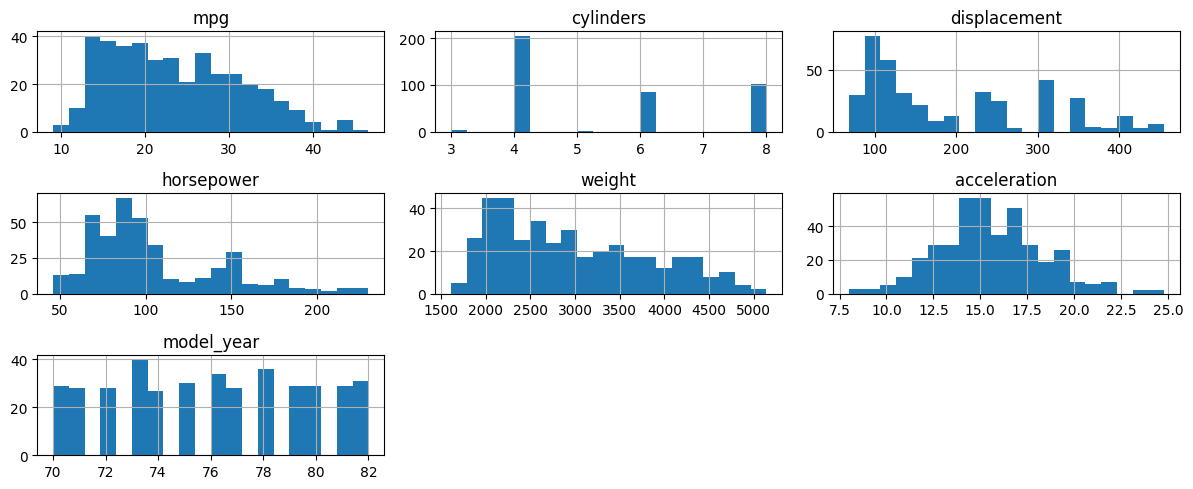

In [5]:
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

df[numeric_cols].hist(figsize=(12,5),bins=20)
plt.tight_layout()
plt.show()

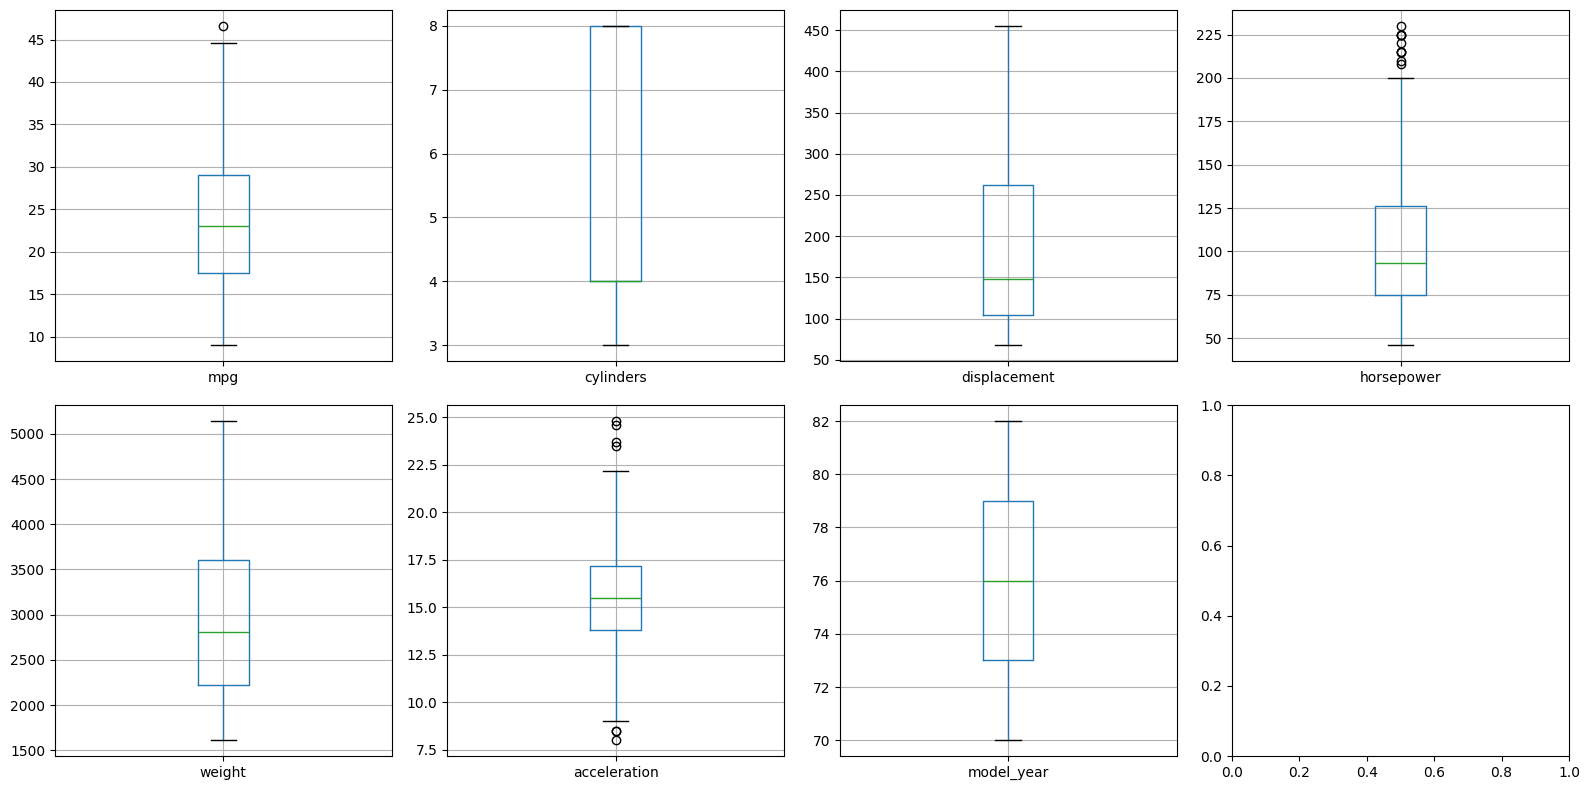

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])

plt.tight_layout()
plt.show()

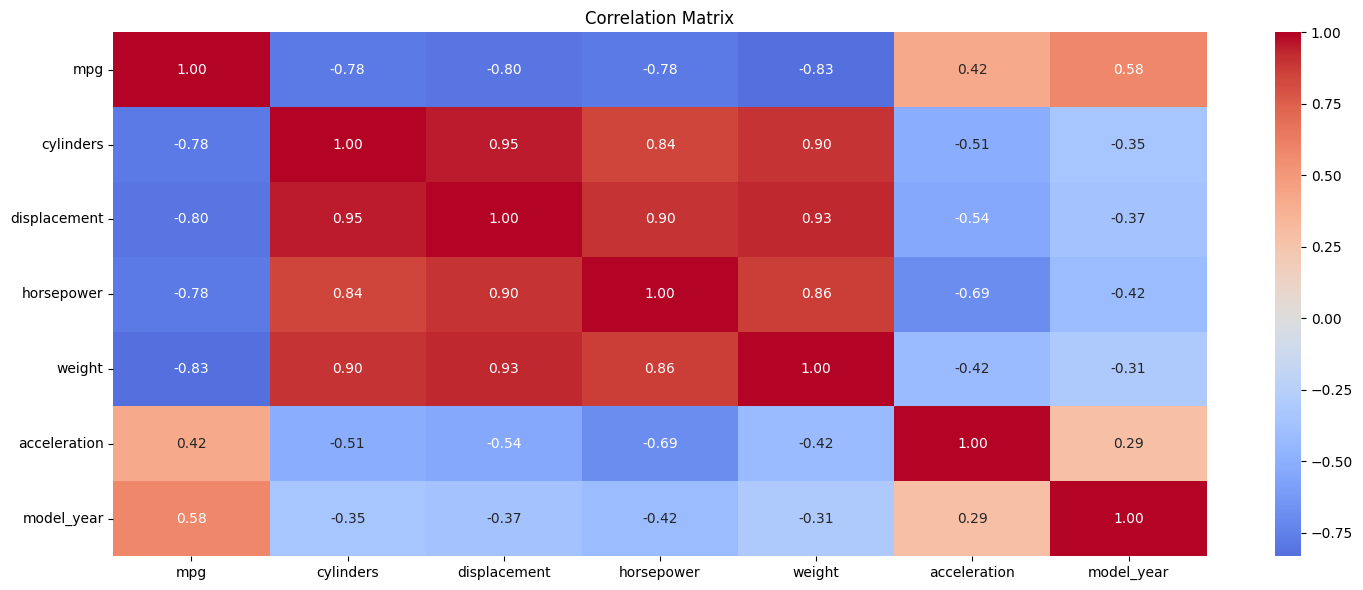

In [7]:
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(15,6))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title("Correlation Matrix")
plt.tight_layout()

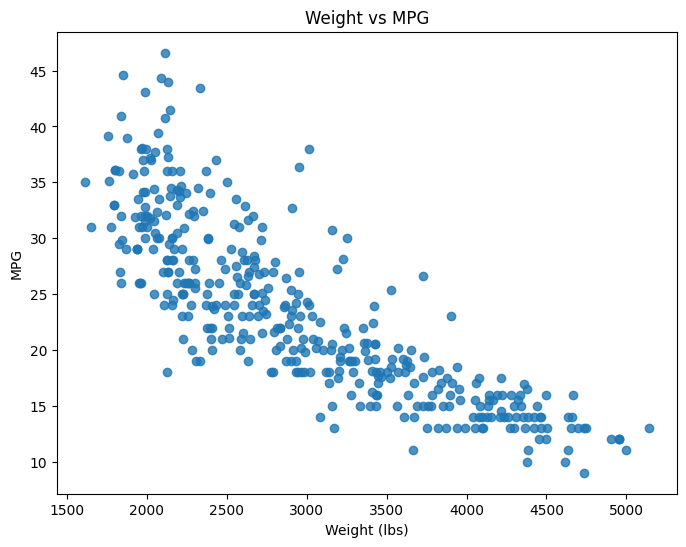

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(df['weight'], df['mpg'], alpha=0.8)
plt.xlabel('Weight (lbs)')
plt.ylabel('MPG')
plt.title('Weight vs MPG')
plt.show()

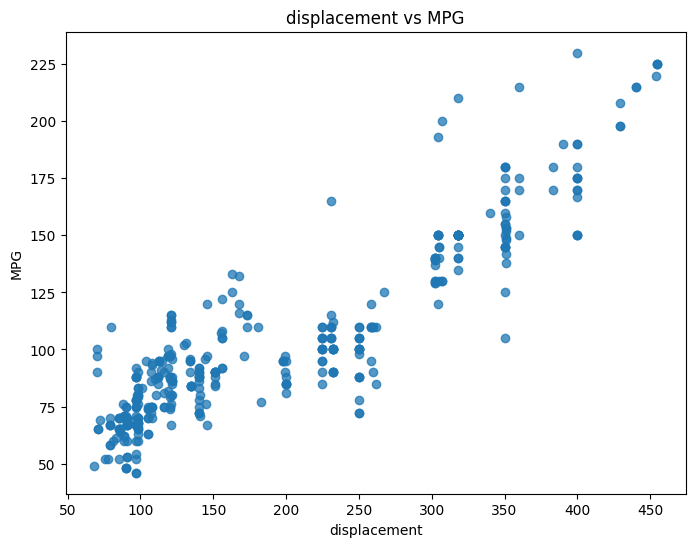

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(df['displacement'],df['horsepower'],alpha=0.75)
plt.xlabel('displacement')
plt.ylabel('MPG')
plt.title('displacement vs MPG')
plt.show()

In [14]:
df[df['horsepower'].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl


In [15]:
df_clean = df.dropna(subset=["horsepower"])

In [19]:
print(f"Filas originales: {df.shape[0]}")
print(f"Filas después de dropna: {df_clean.shape[0]}")
print(f"Nulos restantes en horsepower: {df_clean['horsepower'].isna().sum()}")

Filas originales: 398
Filas después de dropna: 392
Nulos restantes en horsepower: 0


In [22]:
df.to_csv("../datasets/raw/data_raw.csv", index=False)

In [21]:
df_clean.to_csv("../datasets/preprocess/data_processed.csv",index=False)